## Python Language Reference

Pre-course self-study for core Python syntax. Examples assume **Python 3.13** (compatible with 3.10+). Run the version cells below first.

**How to use**
- Run cells **top to bottom** (Kernel → Run All).
- **Optional second pass:** Decorator, Magic (and TOP 10 idioms link).


In [1]:
import datetime
print(datetime.datetime.now())

2026-05-20 21:41:44.560005


In [2]:
# check this out for identifying python version
import sys
print(sys.version_info)

sys.version_info(major=3, minor=13, micro=13, releaselevel='final', serial=0)


### Comments

Use `#` for single-line comments. Python has no true multi-line comment syntax; triple-quoted strings are string literals (often used as docstrings), not comments.


In [3]:
a = 2 # this is a comment
b = 3*3 # another comment

print(a, b)

2 9


In [4]:
# Multi-line notes: use # on each line, or an unused triple-quoted string (not a real comment):
# Line one
# Line two

"""
This is a string literal, not a comment.
Placed at the top of a file it becomes a module docstring.
"""

print("Hello World!")


Hello World!


### Assignment

In [5]:
# assignment
a, b, c = 1, 2, 3

f = 1.2
h = 0x12
s = 1.23e9
d = 1.2e-5

print(a, b, c)
print(f, s, d)

1 2 3
1.2 1230000000.0 1.2e-05


In [6]:
# string assignment
s = "This is"

# string concatenate
s += " a book."

print(s)

This is a book.


In [7]:
# \n and \t are escape characters

s = "this\nis\na\nbook\n"
t = "this\tis\ta\tbook"

print(s)
print(t)

this
is
a
book

this	is	a	book


In [8]:
t = "this is a 'book'"
u = 'this is a "book"'

print(t)
print(u)

this is a 'book'
this is a "book"


### String formatting

**f-strings** (Python 3.6+) are the usual choice; `str.format()` still appears in older code.


In [9]:
name = "DS4CS"
year = 2026
msg = f"Welcome to {name}, year {year}"
print(msg)
print(f"next year: {year + 1}")


Welcome to DS4CS, year 2026
next year: 2027


In [10]:
template = "Welcome to {}, year {}"
print(template.format(name, year))
print("{:.2f}".format(1 / 3))


Welcome to DS4CS, year 2026
0.33


In [11]:
# Python is dynamically typed (a name can refer to different types over time).

a = 18
print(a)
a = "abc"
print(a)


18
abc


### Conditional Selection

In [12]:
t = True

if t:
    print("t is True")

t is True


In [13]:
f = False

if f:
    print("f is True")
else:
    print("f is False")

f is False


In [14]:
i = 10

if i < 0:
    print("Negative")
elif i == 0:
    print("Zero")
else:
    print("Positive")

Positive


### Structural pattern matching (optional, 3.10+)

`match` / `case` replaces long `if`/`elif` chains when checking patterns. Safe to skip on Python older than 3.10.


In [15]:
status = 404
match status:
    case 200:
        print("OK")
    case 404:
        print("Not found")
    case _:
        print("Other status")


Not found


### Repeated Execution

In [16]:
# while loop
k = 3
while k > 0:
    k = k - 1
    print(k)

2
1
0


In [17]:
# for loop
for i in range(3):
    print(i)

0
1
2


### `break` and `continue`

- `break` — exit the innermost loop early.
- `continue` — skip to the next iteration.


In [18]:
# break: stop when n == 3
for n in range(5):
    if n == 3:
        break
    print(n, end=" ")
print()

# continue: skip even numbers
for n in range(5):
    if n % 2 == 0:
        continue
    print(n, end=" ")
print()


0 1 2 
1 3 


### Function

In [19]:
def func():
    pass

def power2(x):
    return x*x

In [20]:
y = power2(3)
print(y)

9


In [21]:
# multiple returns
def mfunc(x, y):
    return y, x

a, b = mfunc(3, 5)
print(a, b)


5 3


### Parameters: defaults, `*args`, `**kwargs`

Later decorator examples pass `*args` and `**kwargs` through wrappers—read this first.


In [22]:
def greet(name, greeting="Hello"):
    return f"{greeting}, {name}"

print(greet("Ada"))
print(greet("Ada", greeting="Hi"))

def show_args(*args, **kwargs):
    print("args:", args)
    print("kwargs:", kwargs)

show_args(1, 2, 3, debug=True)


Hello, Ada
Hi, Ada
args: (1, 2, 3)
kwargs: {'debug': True}


### Lambda Function


In [23]:
# lambda
f1 = lambda x: x*x

y = f1(10)
print(y)

100


In [24]:
# f1 and f2 are identical.

def f2(x):
    return x*x

y = f2(10)
print(y)

100


In [25]:
# Swap without a temp variable (tuple unpacking)
x, y = 1, 2
x, y = y, x
print(x, y)

# lambda: one expression only — return a tuple
swap = lambda a, b: (b, a)
x, y = swap(1, 2)
print(x, y)


2 1
2 1


### Function Scope

In [26]:
def f(x):
    x = x + 1
    return x

x = 10
y = f(x)
print(x, y)

10 11


In [27]:
def f():
    global w
    w = w + 1

w = 10
f()
print(w)

11


### Exceptions (`try` / `except` / `raise`)

Handle expected failures without stopping the whole program.


In [28]:
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return None

print(safe_divide(10, 2))
print(safe_divide(10, 0))


5.0
None


In [29]:
def positive_only(n):
    if n <= 0:
        raise ValueError("n must be positive")
    return n

try:
    positive_only(-1)
except ValueError as e:
    print("caught:", e)


caught: n must be positive


### Class
https://docs.python.org/3/reference/datamodel.html

In [30]:
class MyList:

    length = None
    li = None

    def __init__(self, num=0):
        self.li = list(range(num))
        self.length = num

    def __len__(self):
        return self.length

    def __iter__(self):
        return iter(self.li)

    def __getitem__(self, index):
        return self.li[index]

    def __str__(self):
        return "class MyList, len = %d" % self.length

    def __eq__(self, other):
        return self.length == other.length


In [31]:
ml = MyList()
print(ml)
print(str(ml))

print(ml.length)
print(len(ml))

class MyList, len = 0
class MyList, len = 0
0
0


In [32]:
ml2 = MyList(5) # Try to modify __init__()
print(ml2)

class MyList, len = 5


In [33]:
print(ml == ml2)
# Try to modify __eq__()

False


In [34]:
print(ml2[0])

0


In [35]:
for item in ml2:
    print(item)

0
1
2
3
4


### Import and Utility

In [36]:
import math

print(math.sin(1))

0.8414709848078965


In [37]:
# Optional: help(math) prints the full module reference (very long on Run All).
# help(math)
print("peek:", math.sin.__doc__.strip().split(chr(10))[0])


peek: Return the sine of x (measured in radians).


In [38]:
dir(math)

['__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'acos',
 'acosh',
 'asin',
 'asinh',
 'atan',
 'atan2',
 'atanh',
 'cbrt',
 'ceil',
 'comb',
 'copysign',
 'cos',
 'cosh',
 'degrees',
 'dist',
 'e',
 'erf',
 'erfc',
 'exp',
 'exp2',
 'expm1',
 'fabs',
 'factorial',
 'floor',
 'fma',
 'fmod',
 'frexp',
 'fsum',
 'gamma',
 'gcd',
 'hypot',
 'inf',
 'isclose',
 'isfinite',
 'isinf',
 'isnan',
 'isqrt',
 'lcm',
 'ldexp',
 'lgamma',
 'log',
 'log10',
 'log1p',
 'log2',
 'modf',
 'nan',
 'nextafter',
 'perm',
 'pi',
 'pow',
 'prod',
 'radians',
 'remainder',
 'sin',
 'sinh',
 'sqrt',
 'sumprod',
 'tan',
 'tanh',
 'tau',
 'trunc',
 'ulp']

In [39]:
import math as m
print(m.sin(1))

0.8414709848078965


In [40]:
from math import exp
print(exp(1))

2.718281828459045


In [41]:
from math import exp as e  # may collide with another name 'e'
print(e(1))


2.718281828459045


In [42]:
# Star imports work but pollute the namespace; prefer explicit imports in real code.
from math import *
cos(1)


0.5403023058681398

In [43]:
# dir() does not list the names of all built-in functions and variables.
# In Python 3 they live in the standard module builtins.
# In Jupyter, extra IPython names (e.g. execfile) may appear — not all are CPython builtins.
import builtins
print(dir(builtins))


['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'None', 'NotADirectoryError', 'NotImplemented', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'PythonFinalizationError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning

In [44]:
# Without arguments, dir() lists the names you have defined currently
dir()

['In',
 'MyList',
 'Out',
 '_',
 '_38',
 '_42',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'a',
 'acos',
 'acosh',
 'asin',
 'asinh',
 'atan',
 'atan2',
 'atanh',
 'b',
 'builtins',
 'c',
 'cbrt',
 'ceil',
 'comb',
 'copysign',
 'cos',
 'cosh',
 'd',
 'datetime',
 'degrees',
 'dist',
 'e',
 'erf',
 'erfc',
 'exit',
 'exp',
 'exp2',
 'expm1',
 'f',
 'f1',
 'f2',
 'fabs',
 'factorial',
 'floor',
 'fma',
 'fmod',
 'frexp',
 'fsum',
 'func',
 'gamma',
 'gcd',
 'get_i

### `if __name__ == "__main__"`

In a `.py` file, code under this guard runs only when the file is executed as a script, not when it is imported.


In [45]:
def _demo_main():
    print("main logic runs")

# Notebook kernels usually set __name__ to "__main__"
if __name__ == "__main__":
    _demo_main()
else:
    print("__name__ =", repr(__name__))


main logic runs


### The `with` statement

`with` uses a **context manager** so setup/cleanup (e.g. closing a file) happens automatically.


In [46]:
sample_path = "_p01_with_demo.txt"
with open(sample_path, "w", encoding="utf-8") as f:
    f.write("demo\n")
with open(sample_path, encoding="utf-8") as f:
    print(f.read().strip())
import os
os.remove(sample_path)


demo


### The Zen of Python

In [47]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


### Google Python Style Guide

In [48]:
# https://google.github.io/styleguide/pyguide.html
# Read this document!

### TOP 10 PYTHON IDIOMS I WISH I'D LEARNED EARLIER

Extension reading (not required for Run All):

https://github.com/Prooffreader/Misc_ipynb/blob/master/top_10_python_idioms.ipynb


### Decorator

Optional advanced topic. Understand **Function**, **Function Scope**, and **Parameters (`*args` / `**kwargs`)** first. Revisit later if this feels dense.


In [49]:
# function can be a parameter, and can be a "pointer".
def func1(x):
    return x*x

In [50]:
print(func1(3))

9


In [51]:
func2 = func1
print(func2(4))

16


In [52]:
def func3(x):
    def func4(x):
        return x*2
    return func4(x)*2

In [53]:
print(func3(3))

12


In [54]:
# ChrismasTree example

# decorator
def ChrismasTree(func):
    def my_wrap(*args, **kwargs):
        print("pos 1 ....")
        print("pos 2 ....")
        out = func(*args, **kwargs)
        print("pos 3 ....")
        print("my name is: ", func.__name__)
    return my_wrap

# callee
@ChrismasTree      # decorator
def Star(color):   # decoration
    # with color do something ...
    print(color)
    return

Star("red")
print(Star.__name__) # Star = my_wrap

pos 1 ....
pos 2 ....
red
pos 3 ....
my name is:  Star
my_wrap


In [55]:
# ChrismasTree example, same as above

def Star(color):
    # with color do something ...
    print(color)
    return

Star = ChrismasTree(Star)
Star("red")
print(Star.__name__)


pos 1 ....
pos 2 ....
red
pos 3 ....
my name is:  Star
my_wrap


In [56]:
from functools import wraps
# decorator
def ChrismasTree(func):
    @wraps(func) # <--------------------------
    def my_wrap(*args, **kwargs):
        print("pos 1 ....")
        print("pos 2 ....")
        out = func(*args, **kwargs)
        print("pos 3 ....")
        print("my name is: ", func.__name__)
    return my_wrap

# callee
@ChrismasTree
def Star(color):
    # with color do something ...
    print(color)
    return

Star("red")
print(Star.__name__)

pos 1 ....
pos 2 ....
red
pos 3 ....
my name is:  Star
Star


In [57]:
# log example
def logged(func):
    def with_logging(*args, **kwargs):
        print("{} was called".format(func.__name__))
        return func(*args, **kwargs)
    return with_logging

In [58]:
@logged
def f(x):
    return x + x * x

In [59]:
print(f(5))

f was called
30


In [60]:
# log example, same as above
def f(x):
    return x + x * x

f = logged(f)
print(f(3))

f was called
12


In [61]:
type(f)

function

In [62]:
# html example

def makebold(fn):
    def wrapped():
        return "<b>" + fn() + "</b>"
    return wrapped

def makeitalic(fn):
    def wrapped():
        return "<i>" + fn() + "</i>"
    return wrapped

@makeitalic
@makebold
def hello():
    return "hello world"

In [63]:
print(hello())

<i><b>hello world</b></i>


In [64]:
# With class
class entryExit:

    def __init__(self, f):
        print('entry init enter')
        self.f = f
        print('entry init exit')

    def __call__(self, *args):
        print("Entering {}".format(self.f.__name__))
        r = self.f(*args)
        print("Exited {}".format(self.f.__name__))
        return r

print('decorator using')

@entryExit
def hello(a):
    print('inside hello')
    return "hello world " + a

print('test start')
print(hello('friends'))


decorator using
entry init enter
entry init exit
test start
Entering hello
inside hello
Exited hello
hello world friends


### Magic (Jupyter / IPython)

Optional second pass. **`%%timeit`** is the most useful day to day. The `%matplotlib` line is kept for portability (see comment in the next cell).


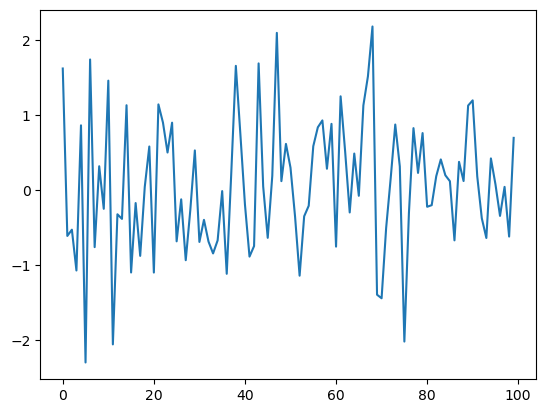

In [65]:
# Many Jupyter / VS Code setups already display plots inline.
# Colab often does too. Keep the next line when figures do not show inline.
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
data = np.random.randn(100)
plt.plot(data)


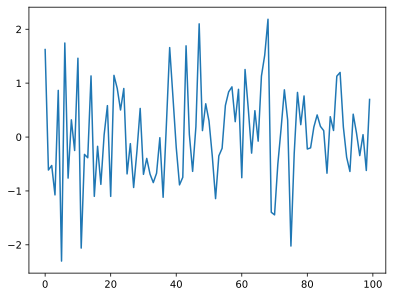

In [66]:
# SVG renders crisply in modern Jupyter; useful for slides and scaling.
%config InlineBackend.figure_format = 'svg'
plt.plot(data)


In [67]:
# IPython magics — Jupyter / IPython only (not valid in plain .py)
# Day to day: %matplotlib inline, %timeit, %%timeit
# Full reference (long output): uncomment %magic or run %lsmagic
# https://ipython.readthedocs.io/en/stable/interactive/magic-commands.html


In [68]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  %%jav

In [69]:
i = 0
%timeit for i in range(1000): i = i+1 # single line magic

13.9 μs ± 991 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [70]:
%%timeit # cell magic
i = 0
for i in range(1000):
    i += 1

16 μs ± 2.31 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
